<h2>Sistema de encendido de turbinas de gas - Conjunto de datos de fallos extremos para la investigación en PHM</h2>

<h2>Se desea inferir los ciclos de vida restantes(y)</h2>

In [1]:
# Esta celda importa librerías para manejo de datos, álgebra y gráficos.
# Sirve para preparar el entorno antes del entrenamiento del modelo.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para algunas gráficas 3D

%matplotlib inline

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en encontrado: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Dispositivo en uso: {device}')

Dispositivo en encontrado: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo en uso: cuda


In [ ]:
# 1. Definición de la clase Dataset 
class BoeingIgnitionDataset(Dataset):
    def __init__(self, X, y):
        # Guardamos como tensores float32
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Forma (N, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


Las columnas excluidas son las siguientes

*4 el 94.9% de los datos son NAN
*7 por que todos los datos estan en nan
*24-28 son datos iguales 
*35-36 son ids

columnas iguales
18-20(excluida)
29-30(excluida)
31-32(excluida)
37-38(excluida)

In [3]:
# Esta celda define la ruta del dataset local.
# Sirve para reemplazar dependencias de Google Colab en VS Code.
dataset = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio2\ignition_health_EXTREME_FAULTS_v42_B787.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')

Archivo a usar: E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio2\ignition_health_EXTREME_FAULTS_v42_B787.csv


In [ ]:
df = pd.read_csv(dataset, sep=',', header=None)

# 1. Limpia y convierte TODAS las columnas de texto primero
diccionario1 = {'healthy': 0, 'failure': 1, 'critical': 2, 'caution': 3, 'monitor': 4}
nombre_col = df.columns[22]
df[nombre_col] = df[nombre_col].str.strip().map(diccionario1)


#forma de limpiar y convertir varias columnas de texto a números 
cols_texto = [29, 31, 37]
for col in cols_texto:
    nombre_col = df.columns[col]
    df[nombre_col] = df[nombre_col].str.strip()

for col in cols_texto:
    nombre_col = df.columns[col]
    df[nombre_col], categorias = pd.factorize(df[nombre_col])
    print(f"Columna {col}: {list(categorias)}")




y = df.iloc[:, 17].values

excluir = np.r_[4, 6, 7, 17,20, 24:29,30,32, 35:37, 38]
X_idx = [i for i in range(df.shape[1]) if i not in excluir]
X = df.iloc[:, X_idx].values


m = y.size



# Division de los datos en entrenamiento y prueba (80% - 20%)

X_train =X[:21600]
X_test =X[21600:]
y_train = y[:21600]
y_test = y[21600:]



print(X.shape)
print(X.dtype)  # debería salir float64, no object
print(np.isnan(X.astype(float)).sum())  # debería salir 0

Columna 29: ['NORMAL_OPERATION', 'REPLACE_IGNITER_URGENT', 'INSPECT_EXCITER_BOX', 'MONITOR_PERFORMANCE']
Columna 31: ['GO', 'NO_GO', 'CONDITIONAL']
Columna 37: ['normal', 'misfire', 'severe_degradation', 'hot_start', 'hung_start', 'igniter_fouling', 'electrode_erosion', 'insulation_breakdown', 'exciter_box_failure']
(27000, 24)
float64
0


In [5]:
# Normalización z-score basada en Train
mu = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0  # Evita división entre cero

X_train_norm = (X_train - mu) / std
X_test_norm = (X_test - mu) / std

In [6]:
# 2. Instanciamos los Datasets con los datos normalizados
train_dataset = BoeingIgnitionDataset(X_train_norm, y_train)
test_dataset = BoeingIgnitionDataset(X_test_norm, y_test)
# 3. Creamos los DataLoaders
# batch_size=128 es ideal para datasets tabulares de este tamaño (~21,600 filas)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"Total batches de entrenamiento por época: {len(train_loader)}")
print(f"Total batches de prueba: {len(test_loader)}")

Total batches de entrenamiento por época: 169
Total batches de prueba: 43


In [7]:
#verificar que no haya datos no numéricos en las columnas de X
for i in X_idx:
    col = df.iloc[:, i]
    # intenta ver si hay valores no convertibles a número
    no_numericos = pd.to_numeric(col, errors='coerce').isna() & col.notna()
    if no_numericos.any():
        print(f"Columna {i} tiene valores no numéricos, ejemplo: {col[no_numericos].unique()[:5]}")

In [8]:
#codigo para conteo de valores NaN/None en una columna específica
# for i in [4]:
#     nombre_col = df.columns[i]
#     total_nan = df[nombre_col].astype(str).str.strip().isin(['NaN', 'None']).sum()
#     print(f"Columna {i}: {total_nan} de {len(df)} filas son NaN/None ({100*total_nan/len(df):.1f}%)")

In [9]:
print(y_train.shape)
print(y_train)

(21600,)
[453 496 485 ... 149  29  74]


In [10]:
print(X_train.shape)  # debería salir (n, m)
print(X_train)
print(X_test.shape)  # debería salir (n, m)

(21600, 24)
[[4.22373874e+00 2.12113739e+03 1.89908404e+01 ... 1.00000000e+00
  4.03000000e+02 0.00000000e+00]
 [2.96875736e+00 1.77831064e+03 1.59214644e+01 ... 1.00000000e+00
  4.46000000e+02 0.00000000e+00]
 [3.91760137e+00 2.04282139e+03 1.82896663e+01 ... 1.00000000e+00
  4.35000000e+02 0.00000000e+00]
 ...
 [7.63538203e-01 1.29268687e+03 9.50009410e+00 ... 1.00000000e+00
  1.00000000e+01 4.00000000e+00]
 [6.92751508e-01 1.27563629e+03 9.39026626e+00 ... 0.00000000e+00
  0.00000000e+00 4.00000000e+00]
 [7.32767477e-01 1.33078029e+03 1.10315562e+01 ... 1.00000000e+00
  1.00000000e+01 4.00000000e+00]]
(5400, 24)


In [ ]:
# Definicion de arquitectura de la red neuronal secuencual
D_in, H, D_out = 24, 16, 1
criterion = torch.nn.MSELoss()


=== ENTRENANDO MODELO 1 (ADAM) CON EARLY STOPPING ===
Época 001/50 - Train MSE: 23383.98 | Test MSE: 1645.80 (Mejor modelo guardado)
Época 010/50 - Train MSE: 828.84 | Test MSE: 720.15 
Época 020/50 - Train MSE: 805.23 | Test MSE: 760.83 

--> Early Stopping activado en Época 24: la pérdida en Test no mejoró en 20 épocas consecutivas.
--> Entrenamiento detenido automáticamente para evitar sobreajuste (Overfitting).

----------------------- RESULTADOS EN TEST (MEJOR ADAM) -----------------------
Mejor MSE en Test: 624.27
Error Porcentual Medio (MAPE): 48.88%
Precisión del Modelo (R²): 74.49%
-------------------------------------------------------------------------------



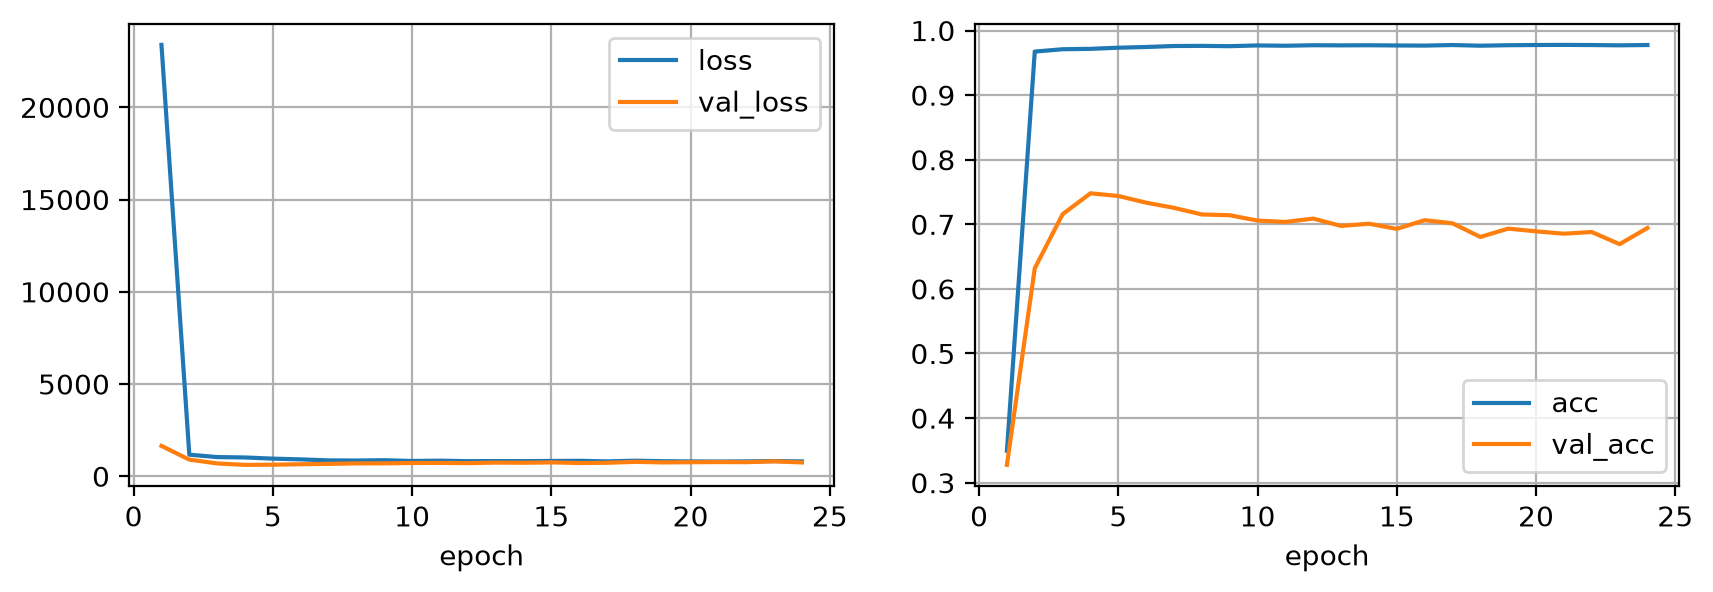

In [ ]:
# ====================================================================
# MODELO 1: ADAM CON REGULARIZACIÓN Y EARLY STOPPING
# ====================================================================
BEST_MODEL_ADAM_PATH = 'best_model_adam.pt'

model_adam = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.1),  
    torch.nn.Linear(H, D_out)
).to(device)

# 2. Optimizador con Weight Decay (Regularización L2 - Cuadernillo 05)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.01, weight_decay=1e-4)

# 3. Parámetros de Early Stopping
epochs = 50
patience = 20  # Número de épocas a esperar sin mejora antes de detener el entrenamiento
patience_counter = 0
best_val_loss_adam = float('inf')

loss_history_train_adam = []
loss_history_val_adam = []


var_y_train = float(np.var(y_train))
var_y_test = float(np.var(y_test))
hist_adam = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print('=== ENTRENANDO MODELO 1 (ADAM) CON EARLY STOPPING ===')
for epoch in range(1, epochs + 1):
    # --- Modo entrenamiento por mini-batches ---
    model_adam.train()
    batch_losses = []
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer_adam.zero_grad()
        pred = model_adam(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer_adam.step()
        
        batch_losses.append(loss.item())
        
    train_loss = float(np.mean(batch_losses))
    loss_history_train_adam.append(train_loss)

    # --- Modo evaluación en Test ---
    model_adam.eval()
    val_losses = []
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_loss = criterion(model_adam(x_val), y_val)
            val_losses.append(val_loss.item())
            
    val_loss = float(np.mean(val_losses))
    loss_history_val_adam.append(val_loss)

    # Cálculo de métricas de precisión R² (coeficiente de determinación)
    train_acc = max(0.0, 1.0 - (train_loss / var_y_train))
    val_acc = max(0.0, 1.0 - (val_loss / var_y_test))

    hist_adam['epoch'].append(epoch)
    hist_adam['loss'].append(train_loss)
    hist_adam['val_loss'].append(val_loss)
    hist_adam['acc'].append(train_acc)
    hist_adam['val_acc'].append(val_acc)

    # --- Lógica de Early Stopping ---
    if val_loss < best_val_loss_adam:
        best_val_loss_adam = val_loss
        torch.save(model_adam.state_dict(), BEST_MODEL_ADAM_PATH)
        patience_counter = 0  # Reiniciamos la paciencia al encontrar un mejor resultado
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1  # No hubo mejora
        guardado = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:03d}/{epochs} - Train MSE: {train_loss:.2f} | Test MSE: {val_loss:.2f} {guardado}')

    # Detener si se agota la paciencia para evitar sobreajuste (overfitting)
    if patience_counter >= patience:
        print(f'\n--> Early Stopping activado en Época {epoch}: la pérdida en Test no mejoró en {patience} épocas consecutivas.')
        print(f'--> Entrenamiento detenido automáticamente para evitar sobreajuste (Overfitting).')
        break

# 4. Cargamos SIEMPRE el mejor modelo guardado (no el último sobreajustado)
model_adam.load_state_dict(torch.load(BEST_MODEL_ADAM_PATH, weights_only=False))
model_adam.eval()

with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_norm).float().to(device)
    y_pred_adam = model_adam(X_test_t).cpu().numpy().flatten()

# Métricas finales de regresión
mse_adam = np.mean((y_test - y_pred_adam) ** 2)
mask = y_test != 0
mape_adam = np.mean(np.abs((y_test[mask] - y_pred_adam[mask]) / y_test[mask])) * 100
r2_adam = 1 - (np.sum((y_test - y_pred_adam) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print('\n----------------------- RESULTADOS EN TEST (MEJOR ADAM) -----------------------')
print(f'Mejor MSE en Test: {mse_adam:.2f}')
print(f'Error Porcentual Medio (MAPE): {mape_adam:.2f}%')
print(f'Precisión del Modelo (R²): {r2_adam * 100:.2f}%')
print('-------------------------------------------------------------------------------\n')

hist = hist_adam
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()


=== ENTRENANDO MODELO 2 (SGD) CON EARLY STOPPING ===
Época 001/200 - Train MSE: 54454.98 | Test MSE: 8961.83 (Mejor modelo guardado)
Época 010/200 - Train MSE: 2009.97 | Test MSE: 7146.87 (Mejor modelo guardado)
Época 020/200 - Train MSE: 1225.17 | Test MSE: 5781.81 (Mejor modelo guardado)
Época 030/200 - Train MSE: 1012.81 | Test MSE: 4301.05 (Mejor modelo guardado)
Época 040/200 - Train MSE: 838.20 | Test MSE: 3212.99 (Mejor modelo guardado)
Época 050/200 - Train MSE: 895.79 | Test MSE: 2683.05 (Mejor modelo guardado)
Época 060/200 - Train MSE: 839.41 | Test MSE: 2384.26 (Mejor modelo guardado)
Época 070/200 - Train MSE: 836.61 | Test MSE: 2249.43 (Mejor modelo guardado)
Época 080/200 - Train MSE: 847.08 | Test MSE: 2138.11 (Mejor modelo guardado)
Época 090/200 - Train MSE: 842.54 | Test MSE: 2061.50 
Época 100/200 - Train MSE: 829.26 | Test MSE: 2011.91 
Época 110/200 - Train MSE: 827.85 | Test MSE: 1923.78 
Época 120/200 - Train MSE: 804.56 | Test MSE: 1863.08 (Mejor modelo guardad

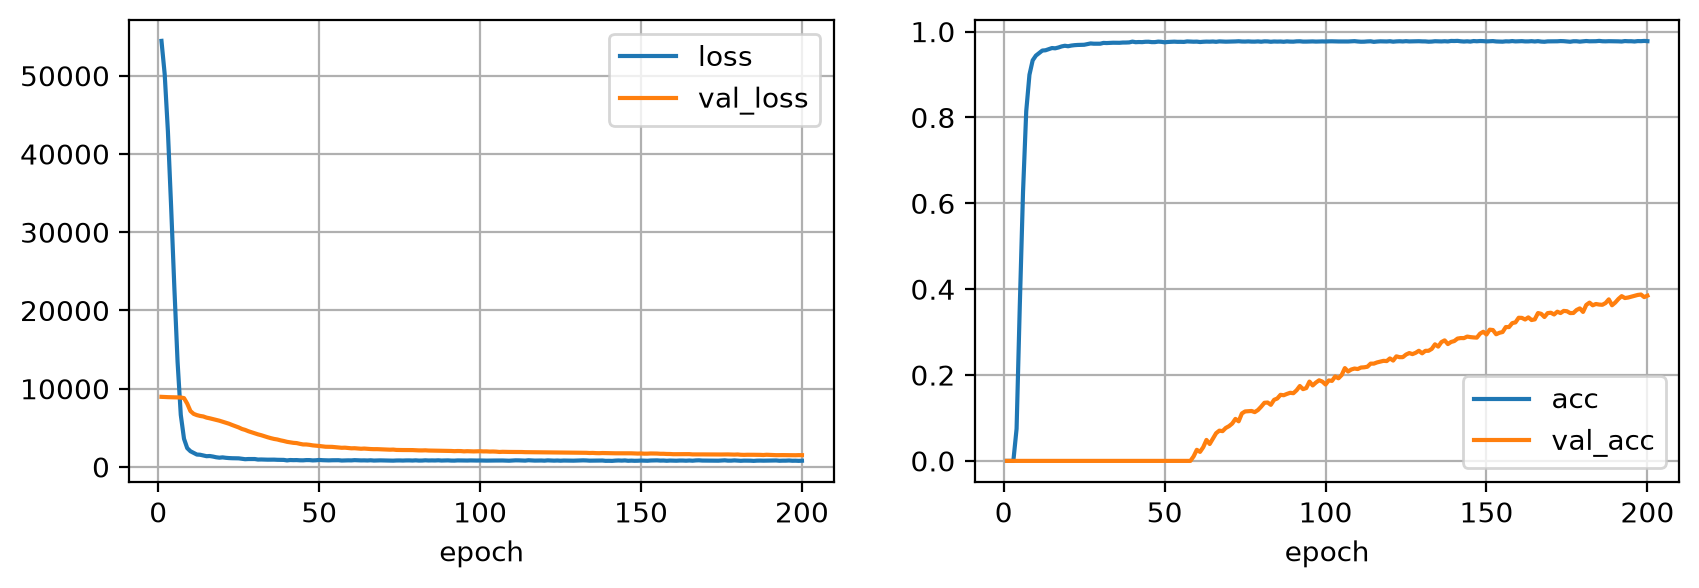

In [ ]:
# ====================================================================
# MODELO 2: SGD CON REGULARIZACIÓN Y EARLY STOPPING
# ====================================================================
BEST_MODEL_SGD_PATH = 'best_model_sgd.pt'

# 1. Definición del modelo con Dropout
model_sgd = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.1),  
    torch.nn.Linear(H, D_out)
).to(device)

# 2. Optimizador con Weight Decay (Regularización L2)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, weight_decay=1e-4)

# 3. Parámetros de Early Stopping
epochs = 200
patience = 20
patience_counter = 0
best_val_loss_sgd = float('inf')

loss_history_train_sgd = []
loss_history_val_sgd = []

hist_sgd = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print('=== ENTRENANDO MODELO 2 (SGD) CON EARLY STOPPING ===')
for epoch in range(1, epochs + 1):
    # --- Modo entrenamiento por mini-batches ---
    model_sgd.train()
    batch_losses = []
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer_sgd.zero_grad()
        pred = model_sgd(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        
        # Recorte de gradientes para evitar explosión
        torch.nn.utils.clip_grad_norm_(model_sgd.parameters(), max_norm=1.0)
        optimizer_sgd.step()
        
        batch_losses.append(loss.item())
        
    train_loss = float(np.mean(batch_losses))
    loss_history_train_sgd.append(train_loss)

    # --- Modo evaluación en Test ---
    model_sgd.eval()
    val_losses = []
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_loss = criterion(model_sgd(x_val), y_val)
            val_losses.append(val_loss.item())
            
    val_loss = float(np.mean(val_losses))
    loss_history_val_sgd.append(val_loss)

    # Cálculo de métricas de precisión R² (coeficiente de determinación)
    train_acc = max(0.0, 1.0 - (train_loss / var_y_train))
    val_acc = max(0.0, 1.0 - (val_loss / var_y_test))

    hist_sgd['epoch'].append(epoch)
    hist_sgd['loss'].append(train_loss)
    hist_sgd['val_loss'].append(val_loss)
    hist_sgd['acc'].append(train_acc)
    hist_sgd['val_acc'].append(val_acc)

    # --- Lógica de Early Stopping ---
    if val_loss < best_val_loss_sgd:
        best_val_loss_sgd = val_loss
        torch.save(model_sgd.state_dict(), BEST_MODEL_SGD_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:03d}/{epochs} - Train MSE: {train_loss:.2f} | Test MSE: {val_loss:.2f} {guardado}')

    # Detener si se agota la paciencia
    if patience_counter >= patience:
        print(f'\n--> Early Stopping activado en Época {epoch}: la pérdida en Test no mejoró en {patience} épocas consecutivas.')
        print(f'--> Entrenamiento detenido automáticamente para evitar sobreajuste (Overfitting).')
        break

# 4. Cargamos SIEMPRE el mejor modelo guardado
model_sgd.load_state_dict(torch.load(BEST_MODEL_SGD_PATH, weights_only=False))
model_sgd.eval()

with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_norm).float().to(device)
    y_pred_sgd = model_sgd(X_test_t).cpu().numpy().flatten()

# Métricas finales
mse_sgd = np.mean((y_test - y_pred_sgd) ** 2)
mask = y_test != 0
mape_sgd = np.mean(np.abs((y_test[mask] - y_pred_sgd[mask]) / y_test[mask])) * 100
r2_sgd = 1 - (np.sum((y_test - y_pred_sgd) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print('\n----------------------- RESULTADOS EN TEST (MEJOR SGD) -----------------------')
print(f'Mejor MSE en Test: {mse_sgd:.2f}')
print(f'Error Porcentual Medio (MAPE): {mape_sgd:.2f}%')
print(f'Precisión del Modelo (R²): {r2_sgd * 100:.2f}%')
print('-------------------------------------------------------------------------------\n')

hist = hist_sgd
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()


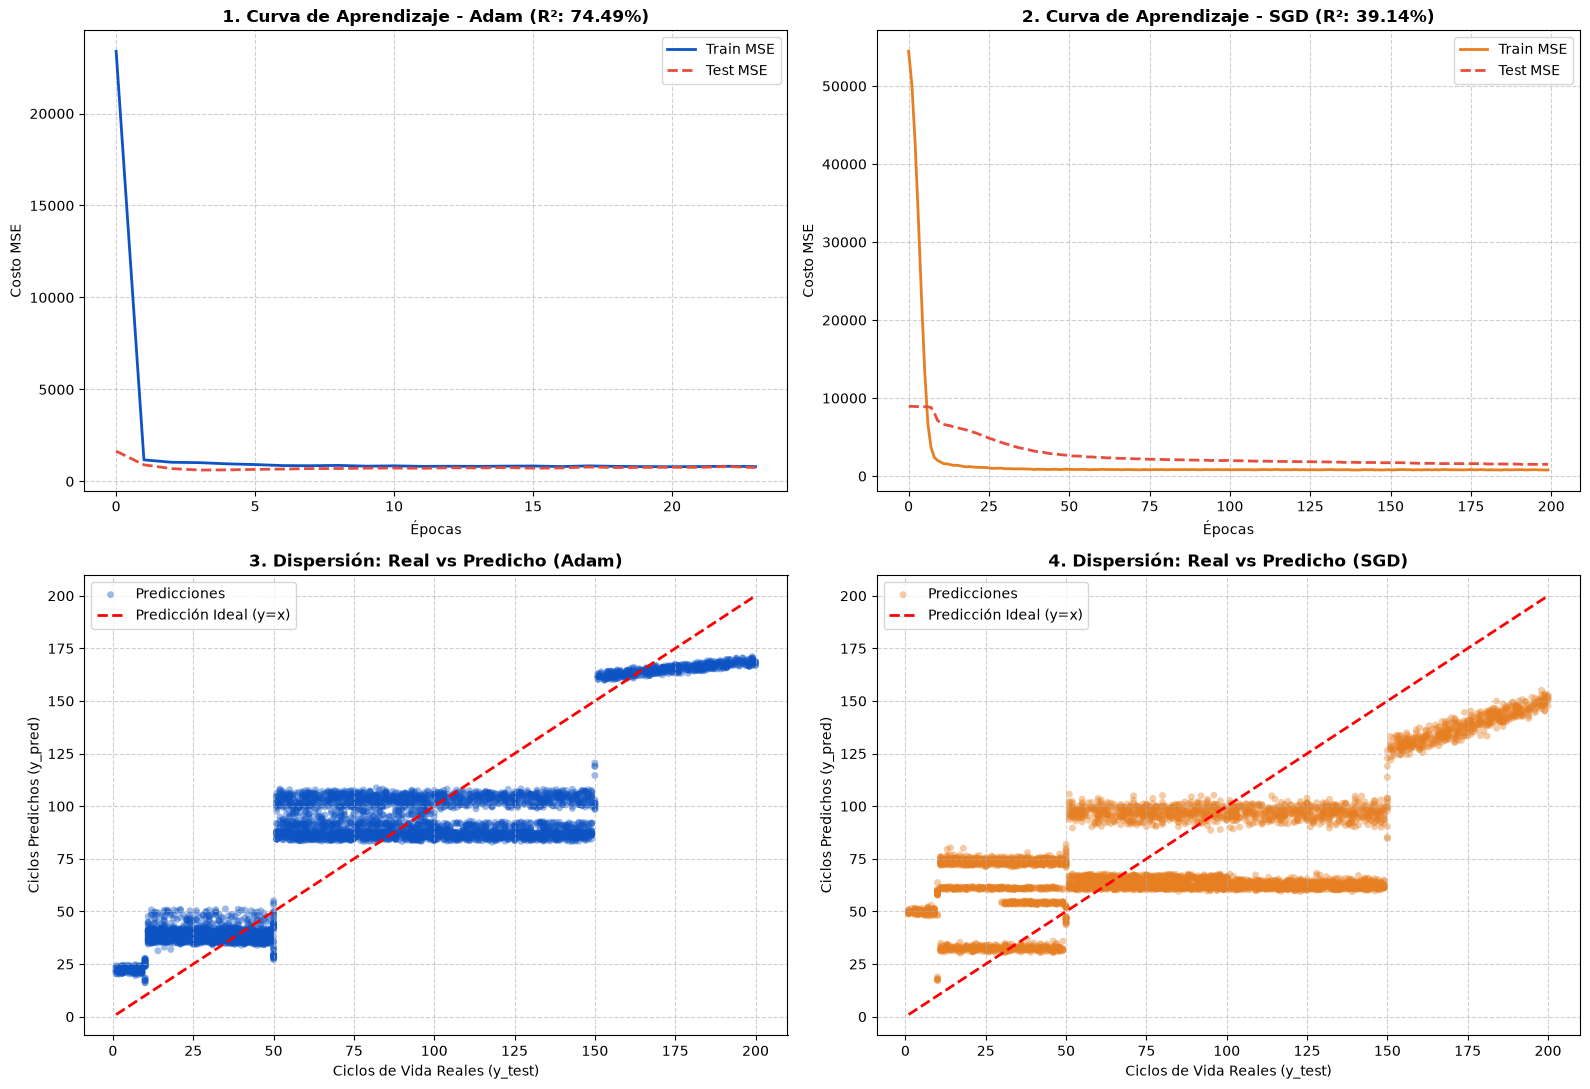

=================== RESUMEN COMPARATIVO DE MODELOS PYTORCH ===================
Modelo 1 (Adam) -> MSE: 624.27 | RMSE: ±24.99 ciclos | MAPE: 48.88% | R²: 74.49%
Modelo 2 (SGD)  -> MSE: 1489.48 | RMSE: ±38.59 ciclos | MAPE: 95.84% | R²: 39.14%


In [14]:
# ====================================================================
# DIAGNÓSTICO DE REGULARIZACIÓN Y COMPARATIVA (¿APRENDE O MEMORIZA?)
# ====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Curva de Regularización - Adam (Train vs Test Loss)
axes[0, 0].plot(loss_history_train_adam, color='#0d53c4', lw=2, label='Train MSE')
axes[0, 0].plot(loss_history_val_adam, color='#e74c3c', lw=2, linestyle='--', label='Test MSE')
axes[0, 0].set_title(f'1. Curva de Aprendizaje - Adam (R²: {r2_adam * 100:.2f}%)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Épocas')
axes[0, 0].set_ylabel('Costo MSE')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].legend()

# 2. Curva de Regularización - SGD (Train vs Test Loss)
axes[0, 1].plot(loss_history_train_sgd, color='#e67e22', lw=2, label='Train MSE')
axes[0, 1].plot(loss_history_val_sgd, color='#e74c3c', lw=2, linestyle='--', label='Test MSE')
axes[0, 1].set_title(f'2. Curva de Aprendizaje - SGD (R²: {r2_sgd * 100:.2f}%)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Épocas')
axes[0, 1].set_ylabel('Costo MSE')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].legend()

# 3. Dispersión Real vs Predicho - Adam
axes[1, 0].scatter(y_test, y_pred_adam, color='#0d53c4', alpha=0.4, edgecolors='none', s=25, label='Predicciones')
min_val = min(y_test.min(), y_pred_adam.min())
max_val = max(y_test.max(), y_pred_adam.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Predicción Ideal (y=x)')
axes[1, 0].set_title('3. Dispersión: Real vs Predicho (Adam)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Ciclos de Vida Reales (y_test)')
axes[1, 0].set_ylabel('Ciclos Predichos (y_pred)')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)
axes[1, 0].legend()

# 4. Dispersión Real vs Predicho - SGD
axes[1, 1].scatter(y_test, y_pred_sgd, color='#e67e22', alpha=0.4, edgecolors='none', s=25, label='Predicciones')
min_val_sgd = min(y_test.min(), y_pred_sgd.min())
max_val_sgd = max(y_test.max(), y_pred_sgd.max())
axes[1, 1].plot([min_val_sgd, max_val_sgd], [min_val_sgd, max_val_sgd], color='red', linestyle='--', lw=2, label='Predicción Ideal (y=x)')
axes[1, 1].set_title('4. Dispersión: Real vs Predicho (SGD)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Ciclos de Vida Reales (y_test)')
axes[1, 1].set_ylabel('Ciclos Predichos (y_pred)')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Resumen comparativo en consola
rmse_adam = np.sqrt(mse_adam)
rmse_sgd = np.sqrt(mse_sgd)
print('=================== RESUMEN COMPARATIVO DE MODELOS PYTORCH ===================')
print(f'Modelo 1 (Adam) -> MSE: {mse_adam:.2f} | RMSE: ±{rmse_adam:.2f} ciclos | MAPE: {mape_adam:.2f}% | R²: {r2_adam * 100:.2f}%')
print(f'Modelo 2 (SGD)  -> MSE: {mse_sgd:.2f} | RMSE: ±{rmse_sgd:.2f} ciclos | MAPE: {mape_sgd:.2f}% | R²: {r2_sgd * 100:.2f}%')
print('==============================================================================')


<h1>Ecuacion de la normal</h1>

In [15]:
def normalEqn_pytorch(X, y):
    # Convertimos a tensores de PyTorch en el dispositivo activo (GPU o CPU)
    # Usamos torch.float64 para máxima precisión numérica en la inversión matricial
    X_t = torch.as_tensor(X, dtype=torch.float64, device=device)
    y_t = torch.as_tensor(y, dtype=torch.float64, device=device).unsqueeze(1)
    
    # Ecuación Normal en PyTorch: theta = (X^T @ X)^(-1) @ X^T @ y
    # torch.linalg.pinv calcula la pseudoinversa de Moore-Penrose de forma estable en PyTorch
    XtX = torch.matmul(X_t.T, X_t)
    XtX_inv = torch.linalg.pinv(XtX)
    Xty = torch.matmul(X_t.T, y_t)
    theta = torch.matmul(XtX_inv, Xty)
    return theta


In [16]:
# 1. Estimación analítica óptima de parámetros theta usando tensores PyTorch
theta_pt = normalEqn_pytorch(X_train, y_train)

# 2. Predicciones sobre el conjunto de prueba utilizando multiplicación de tensores PyTorch
X_test_t = torch.as_tensor(X_test, dtype=torch.float64, device=device)
y_test_t = torch.as_tensor(y_test, dtype=torch.float64, device=device).unsqueeze(1)
predicciones_ne = torch.matmul(X_test_t, theta_pt)

# 3. Métricas de costo y evaluación calculadas con PyTorch
criterion_eval = torch.nn.MSELoss()
mse_ne = criterion_eval(predicciones_ne, y_test_t).item()
rmse_ne = np.sqrt(mse_ne)

# Mape y R²
y_test_cpu = y_test_t.cpu().numpy().flatten()
pred_cpu = predicciones_ne.cpu().numpy().flatten()
mask = y_test_cpu != 0
mape_ne = np.mean(np.abs((y_test_cpu[mask] - pred_cpu[mask]) / y_test_cpu[mask])) * 100
var_y = torch.var(y_test_t, unbiased=False).item()
r2_ne = 1.0 - (mse_ne / var_y)

print('------------------ RESULTADOS DE LA ECUACIÓN NORMAL EN PYTORCH ------------------')
print(f'Error Cuadrático Medio (MSE): {mse_ne:.2f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): ±{rmse_ne:.2f} ciclos')
print(f'Error Porcentual Medio (MAPE): {mape_ne:.2f}%')
print(f'Precisión del Modelo (R²): {r2_ne * 100:.2f}%')
print('---------------------------------------------------------------------------------\n')

# ==============================================================================
# TABLA COMPARATIVA FINAL: MODELOS PYTORCH VS ECUACIÓN NORMAL (PYTORCH)
# ==============================================================================
comparativa = pd.DataFrame({
    'Modelo': [
        '1. PyTorch Red Neuronal (Adam)',
        '2. PyTorch Red Neuronal (SGD)',
        '3. PyTorch Ecuación Normal (Analítica)'
    ],
    'MSE': [mse_adam, mse_sgd, mse_ne],
    'RMSE (ciclos)': [rmse_adam, rmse_sgd, rmse_ne],
    'MAPE (%)': [mape_adam, mape_sgd, mape_ne],
    'Precisión R² (%)': [r2_adam * 100, r2_sgd * 100, r2_ne * 100]
})

print('================================ TABLA COMPARATIVA FINAL ================================')
print(comparativa.to_string(index=False))
print('=========================================================================================')


------------------ RESULTADOS DE LA ECUACIÓN NORMAL EN PYTORCH ------------------
Error Cuadrático Medio (MSE): 578.13
Raíz del Error Cuadrático Medio (RMSE): ±24.04 ciclos
Error Porcentual Medio (MAPE): 49.43%
Precisión del Modelo (R²): 76.38%
---------------------------------------------------------------------------------

================================ TABLA COMPARATIVA FINAL ================================
                                Modelo         MSE  RMSE (ciclos)  MAPE (%)  Precisión R² (%)
        1. PyTorch Red Neuronal (Adam)  624.272230      24.985440 48.878071         74.492200
         2. PyTorch Red Neuronal (SGD) 1489.483489      38.593827 95.841644         39.139616
3. PyTorch Ecuación Normal (Analítica)  578.132272      24.044381 49.431371         76.377481


C:\Users\luisg\AppData\Local\Temp\ipykernel_1272\4040121984.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_t = torch.as_tensor(y, dtype=torch.float64, device=device).unsqueeze(1)
